In [1]:
#imports
from datetime import datetime
from operator import index
from random import random
import random
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow
from tensorflow.keras.models import (Sequential, load_model, Model)
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.layers import (Dense, Dropout, Conv1D, GRU, Bidirectional, LSTM, Flatten, Input, concatenate)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint)
from sklearn.metrics import (r2_score, mean_absolute_error)
from math import ceil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

2025-02-09 18:20:57.374000: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-09 18:20:57.389816: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1739121657.408710   41283 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1739121657.414444   41283 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-09 18:20:57.434930: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
# Daten einlesen
df = pd.read_csv('../Neuronales_Netz/Fahrradzaehlung_komplett_rolling_mean_int.csv')

In [3]:
# Zeiteigenschaften setzen und Index machen
df['time'] = pd.to_datetime(df['time'], format='%Y-%m-%d %H:%M:%S')
df = df.set_index('time')

In [4]:
#df.sort_index(inplace=True)

In [5]:
# Netz mit Generator
bruecken = df.columns.values
#df["target"]=df['bruehler_straße'].shift(-1)
X = df[bruecken].values
y = df[[bruecken[0]]].values
split = ceil(len(df)* 0.8)
time_train_gesamt = df.index
time_train = df[:split].index
time_test = df[split:].index
X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]
X_train.shape, X_test.shape, y_train.shape, y_test.shape
#df.dropna(inplace=True)
#df.isna().sum()

((55796, 9), (13949, 9), (55796, 1), (13949, 1))

In [6]:
scaler_x = StandardScaler()
scaler_x.fit(X_train)
X_train = scaler_x.transform(X_train)
X_test = scaler_x.transform(X_test)
scaler_y = StandardScaler()
scaler_y.fit(y_train)
y_train = scaler_y.transform(y_train)
y_test = scaler_y.transform(y_test)

In [7]:
week_means = pd.DataFrame(X, index=time_train_gesamt, columns=bruecken)
week_means = week_means.groupby(week_means.index.isocalendar().week)[week_means.columns].mean()
week_means

,bruehler_straße,estermannufer,kennedybruecke,nordbruecke,suedbruecke,rhenusallee,von_sandt_ufer,weg_auf_dem_damm,wilhelm_spiritus_ufer
week,,,,,,,,,
1,24.444728,20.829082,209.364796,37.896259,73.471088,62.532313,53.074830,63.185374,74.998299
2,26.488562,18.570261,222.387255,35.992647,69.584150,54.606209,48.876634,58.697712,70.214869
3,25.270089,8.333333,219.068452,25.993304,68.594494,35.420387,28.700893,40.149554,53.796131
4,25.574405,8.572173,213.601190,26.569196,69.115327,34.738095,26.722470,39.639137,49.059524
5,26.573661,11.991071,216.764137,30.656994,76.375000,44.755208,35.826637,47.212054,60.295387
6,33.798363,26.197917,272.352679,46.122024,95.307292,78.014137,66.868304,78.034226,96.848214
7,27.395089,14.705357,229.733631,34.795387,80.210565,49.406994,41.747024,57.250000,64.456101
8,27.200149,15.608631,235.552083,36.002976,84.470238,51.636905,43.422619,59.043155,67.239583
9,27.467262,15.754464,239.721726,34.633929,81.018601,50.101190,42.086310,55.078869,66.180060


In [8]:
def data_generator_seasonal(X: np.array, y: np.array, mean_tab: pd.DataFrame, y_index: pd.Index, window=144, horizon=24, season=14, batch_size=1, epochs=10):
    for epoch in range(epochs):
        X_s, X_m, y_ = [], [], []
        batch_counter = 0
        last_val = len(X) - (window + horizon)
        index_range = list(range(last_val))
        random.shuffle(index_range)
        for idx in index_range:
            season_range = range(window+idx-1, idx-1, -season)
            X_s.append([X[i] for i in season_range])
            y_date = y_index[idx+window+horizon]
            y_mean = mean_tab.loc[y_date.week]
            X_m.append(y_mean.values)
            y_.append(y[idx+window+horizon])
            batch_counter += 1
            if (batch_counter == batch_size or index_range[-1] == idx):
                yield ((np.array(X_s), np.array(X_m)), np.array(y_))
                X_s, X_m, y_ = [], [], []
                batch_counter = 0

test_gen = data_generator_seasonal(X_train, y_train, mean_tab=week_means, y_index=time_train)
(x_s, x_m), y_ = next(test_gen)
print(x_s.shape, x_m.shape, y_.shape)

(1, 11, 9) (1, 9) (1, 1)


In [9]:
batch_size = 128
epochs = 100
window = 144
horizon = 24
indicators = 9
num_seasons = 12
reg = l2(0.0001)

input_sn = Input(shape=(num_seasons, indicators), name='in_sn')
input_mn = Input(shape=(indicators,), name='in_mn')

sn = GRU(units=32, dropout=0.3, go_backwards=True, kernel_regularizer=reg, name='sn_gru')(input_sn)
mn = Dense(units=indicators, activation='tanh', kernel_regularizer=reg)(input_mn)
mn = Dropout(0.2)(mn)
comp = concatenate([sn, mn], axis=-1)
comp = Dense(units=1, kernel_regularizer=reg)(comp)

model_seasonal = Model([input_sn, input_mn], comp)
model_seasonal.compile(loss='mse', optimizer='adam', metrics=['mae'])

2025-02-09 18:20:59.509259: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [10]:
gen_train_seasonal = data_generator_seasonal(X_train, y_train, mean_tab=week_means, y_index=time_train, window=window, horizon=horizon, season=num_seasons, batch_size=batch_size, epochs=epochs)
gen_test_seasonal = data_generator_seasonal(X_test, y_test, mean_tab=week_means, y_index=time_test, window=window, horizon=horizon, season=num_seasons, batch_size=batch_size, epochs=epochs)

early = EarlyStopping(monitor='val_loss', patience=10)
check = ModelCheckpoint(filepath='Gesamt_model.keras', monitor='val_loss', save_best_only=True)

steps_train = ceil(len(X_train-(window+horizon))/batch_size)
steps_test = ceil(len(X_test-(window+horizon))/batch_size)

history_seasonal = model_seasonal.fit(gen_train_seasonal, epochs=epochs, steps_per_epoch=steps_train, validation_data=(gen_test_seasonal), validation_steps=steps_test, callbacks=[early, check])
#history_seasonal = model_seasonal.fit(X_train, epochs=epochs, steps_per_epoch=steps_train, validation_data=X_test, validation_steps=steps_test, callbacks=[early, check])

Epoch 1/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.8140 - mae: 0.6688 - val_loss: 0.7175 - val_mae: 0.5060
Epoch 2/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4861 - mae: 0.4970 - val_loss: 0.7114 - val_mae: 0.5185
Epoch 3/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4446 - mae: 0.4671 - val_loss: 0.7285 - val_mae: 0.5292
Epoch 4/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4202 - mae: 0.4499 - val_loss: 0.7043 - val_mae: 0.5169
Epoch 5/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3945 - mae: 0.4336 - val_loss: 0.6930 - val_mae: 0.5166
Epoch 6/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3881 - mae: 0.4306 - val_loss: 0.7212 - val_mae: 0.5409
Epoch 7/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3824 - mae: 0.4242 - val_loss: 0.6695 - val_mae: 0.5032
Epoch 8/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3687 - mae: 0.4179 - val_loss: 0.7083 - val_mae: 0.5287
Epoch 9/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/

Text(0, 0.5, 'loss')

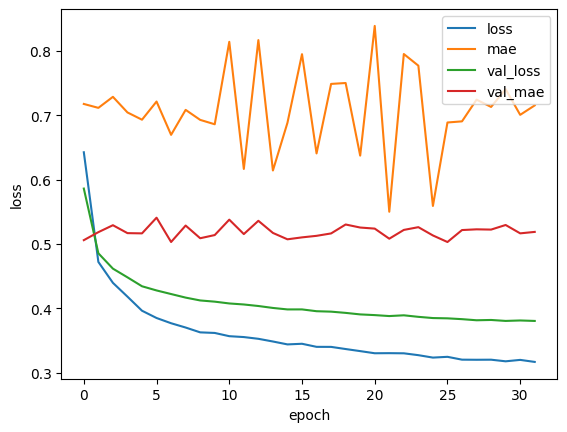

In [11]:
plt.plot(history_seasonal.history['loss'])
plt.plot(history_seasonal.history['val_loss'])
plt.plot(history_seasonal.history['mae'])
plt.plot(history_seasonal.history['val_mae'])
plt.legend(['loss', 'mae', 'val_loss', 'val_mae'])
plt.xlabel('epoch')
plt.ylabel('loss')

In [12]:
model_seasonal.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ in_mn (InputLayer)  │ (None, 9)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ in_sn (InputLayer)  │ (None, 12, 9)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 9)         │         90 │ in_mn[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sn_gru (GRU)        │ (None, 32)        │      4,128 │ in_sn[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 9)         │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 41)        │          0 │ sn_gru[0][0],     │
│ (Concatenate)       │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         42 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,782 (49.93 KB)

 Trainable params: 4,260 (16.64 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,522 (33.29 KB)

In [13]:
loss, acc = model_seasonal.evaluate(gen_test_seasonal, steps=steps_test)

109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.9408 - mae: 0.5187


In [14]:
def data_generator(X, y, window=144, horizon=24, batch_size=1, epochs=10):
    for epoch in range(epochs):
        X_temp = []
        y_temp = []
        batch_counter = 0
        last_val = len(X) - (window + horizon)
        index_range = list(range(last_val))
        random.shuffle(index_range)
        for idx in index_range:
            X_idx = X[idx:idx+window]
            y_idx = y[idx+window+horizon]
            X_temp.append(X_idx)
            y_temp.append(y_idx)
            batch_counter += 1
            if (batch_counter == batch_size or index_range[-1] == idx):
                yield np.array(X_temp), np.array(y_temp).reshape(-1)
                X_temp = []
                y_temp = []
                batch_counter = 0

In [15]:
reg = l2(0.0001)
model = Sequential()
model.add(Conv1D(filters=32, kernel_size=6, input_shape=(144, 9), activation='relu'))
model.add(Dropout(0.3))
model.add(Bidirectional(LSTM(units=32,dropout=0.3,kernel_regularizer=reg)))
model.add(Dense(units=1, kernel_regularizer=reg))
model.compile(loss='mse', optimizer='adam', metrics=['mae'])

/home/leonidas/Uni/Semester_5_24_25/Datenanalyse/Projekt/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
batch_size = 128
epochs = 50
window = 144
horizon = 24

gen_train = data_generator(X_train, y_train, batch_size=batch_size, epochs=epochs)
gen_test = data_generator(X_test, y_test, batch_size=batch_size, epochs=epochs)

early = EarlyStopping(monitor='val_loss', patience=10)
check = ModelCheckpoint(filepath='Conv1D.keras', monitor='val_loss', save_best_only=True)

steps_train = ceil(len(X_train-(window+horizon))/batch_size)
steps_test = ceil(len(X_test-(window+horizon))/batch_size)

historyConv1D = model.fit(gen_train, epochs=epochs, steps_per_epoch=steps_train, validation_data=(gen_test), validation_steps=steps_test, callbacks=[early, check])
#historyConv1D = model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, verbose=1, steps_per_epoch=steps_train, validation_split=0.1, shuffle=1, validation_steps=steps_test, callbacks=[early, check])


Epoch 1/50
436/436 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - loss: 0.5046 - mae: 0.4997 - val_loss: 0.6871 - val_mae: 0.5033
Epoch 2/50
436/436 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - loss: 0.3569 - mae: 0.3946 - val_loss: 0.6816 - val_mae: 0.5081
Epoch 3/50
436/436 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - loss: 0.3351 - mae: 0.3800 - val_loss: 0.6566 - val_mae: 0.4890
Epoch 4/50
436/436 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - loss: 0.3311 - mae: 0.3754 - val_loss: 0.6421 - val_mae: 0.5033
Epoch 5/50
436/436 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - loss: 0.3245 - mae: 0.3717 - val_loss: 0.6710 - val_mae: 0.4983
Epoch 6/50
436/436 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - loss: 0.3153 - mae: 0.3654 - val_loss: 0.7385 - val_mae: 0.4938
Epoch 7/50
436/436 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - loss: 0.3111 - mae: 0.3639 - val_loss: 0.5765 - val_mae: 0.4919
Epoch 8/50
436/436 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - loss: 0.3085 - mae: 0.3614 - val_loss: 0.6742 - val_mae: 0.5016
Epoch 9/50
436/436 ━━━━━━━━━━━━━━━━━━━━ 

In [17]:
def predictions_vs_true(X_pred, y_true, model, scaler, window=144, horizon=24):
    X_temp=[]
    y_temp=[]
    y_temp_simple=[]
    num_pred = len(X_pred)-(window+horizon)
    for idx in range(num_pred):
        X_idx = X_pred[idx:idx+window]
        y_idx = y_true[idx+window+horizon]
        X_temp.append(X_idx)
        y_temp.append(y_idx)
        y_temp_simple.append(y_true[idx+window])
    X_temp = np.array(X_temp)
    y_pred = model.predict(X_temp)
    y_pred = scaler.inverse_transform(y_pred)
    y_temp = scaler.inverse_transform(y_temp)
    y_temp_simple = scaler.inverse_transform(y_temp_simple)
    return y_temp, y_pred, y_temp_simple

In [18]:
model = load_model('Conv1D.keras')
y_true, y_pred, y_simple = predictions_vs_true(X_test, y_test, model=model, scaler = scaler_y)

print('mae, predictions', mean_absolute_error(y_true, y_pred))
print('mae, simple pred', mean_absolute_error(y_simple, y_simple))

431/431 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
mae, predictions 15.928454872408087
mae, simple pred 0.0


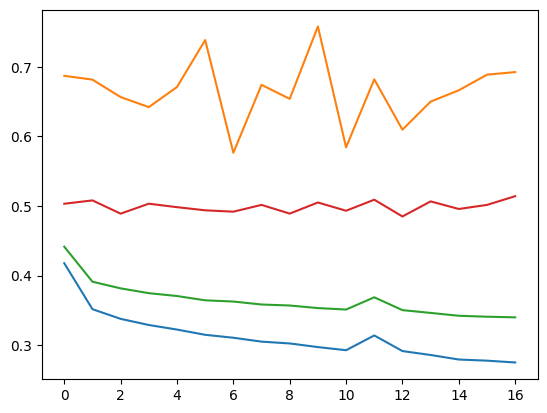

In [19]:
plt.plot(historyConv1D.history['loss'])
plt.plot(historyConv1D.history['val_loss'])
plt.plot(historyConv1D.history['mae'])
plt.plot(historyConv1D.history['val_mae'])

In [20]:
y_pred = model.predict(X_test)


ValueError: Exception encountered when calling Sequential.call().

[1mCannot take the length of shape with unknown rank.[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=<unknown>, dtype=float32)
  • training=False
  • mask=None